In [1]:
import os
import json
from PIL import Image
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm import tqdm

In [2]:
with open("split_indices.json", "r") as f:
    split_data = json.load(f)

In [3]:
root_dir = "/Users/Surface/Documents/GitHub/Neurovision/archive (1)"

In [4]:
all_images = []

for root, dirs, files in os.walk(root_dir):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            rel_path = os.path.join(os.path.relpath(root, root_dir), f)
            all_images.append(rel_path)

all_images = sorted(all_images)

In [5]:
train_files = [all_images[i] for i in split_data["train"]]
val_files   = [all_images[i] for i in split_data["val"]]
test_files  = [all_images[i] for i in split_data["test"]]

In [6]:
class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, file_list, transform=None):
        self.root_dir = root_dir
        self.file_list = file_list
        self.transform = transform

        # FIXED LABEL MAP
        self.label_map = {
            "glioma_tumor": 0,
            "meningioma_tumor": 1,
            "no_tumor": 2,
            "pituitary_tumor": 3
        }

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        full_path = os.path.join(self.root_dir, img_path)

        image = Image.open(full_path).convert("RGB")

        # Training/glioma_tumor/xxx.jpg → glioma_tumor
        label_name = img_path.split("/")[1].lower()
        label = self.label_map[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [8]:
train_dataset = BrainTumorDataset(root_dir, train_files, transform=train_transform)
val_dataset   = BrainTumorDataset(root_dir, val_files, transform=val_test_transform)
test_dataset  = BrainTumorDataset(root_dir, test_files, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

for param in model.parameters():
    param.requires_grad = True

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 4)
)

model = model.to(device)

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

In [11]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [12]:
def evaluate(model, loader):
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            preds.extend(predicted.cpu().numpy())
            trues.extend(labels.numpy())

    acc = accuracy_score(trues, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        trues, preds, average='weighted'
    )

    return acc, precision, recall, f1

In [13]:
best_f1 = 0
patience = 10
wait = 0

for epoch in range(50):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    acc, precision, recall, f1 = evaluate(model, val_loader)

    scheduler.step(train_loss)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val F1={f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        wait = 0
        torch.save(model.state_dict(), "resnet50_best.pth")
    else:
        wait += 1

    if wait >= patience:
        print("Early stopping triggered")
        break

100%|██████████| 72/72 [03:20<00:00,  2.79s/it]


Epoch 1: Train Loss=0.8267, Val F1=0.7915


100%|██████████| 72/72 [03:19<00:00,  2.77s/it]


Epoch 2: Train Loss=0.5799, Val F1=0.7891


100%|██████████| 72/72 [03:20<00:00,  2.78s/it]


...

Epoch 27: Train Loss=0.2540, Val F1=0.8664


100%|██████████| 72/72 [03:38<00:00,  3.03s/it]


Epoch 28: Train Loss=0.3023, Val F1=0.8562


100%|██████████| 72/72 [03:17<00:00,  2.74s/it]


Epoch 29: Train Loss=0.2807, Val F1=0.8509
Early stopping triggered


In [14]:
def evaluate_with_preds(model, loader):
    model.eval()
    preds, trues, probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            softmax = torch.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs, 1)

            preds.extend(predicted.cpu().numpy())
            trues.extend(labels.numpy())
            probs.extend(softmax.cpu().numpy())

    return np.array(trues), np.array(preds), np.array(probs)

import numpy as np

test_trues, test_preds, test_probs = evaluate_with_preds(model, test_loader)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

test_acc = accuracy_score(test_trues, test_preds)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    test_trues, test_preds, average='weighted'
)

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1:        {test_f1:.4f}")

Test Accuracy:  0.8714
Test Precision: 0.8792
Test Recall:    0.8714
Test F1:        0.8717


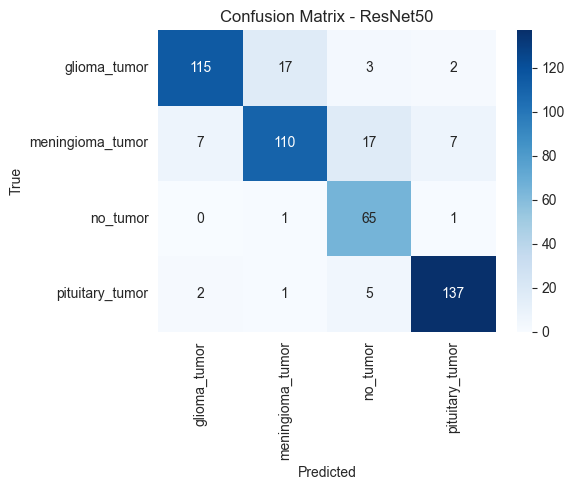

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_names = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]

cm = confusion_matrix(test_trues, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - ResNet50")
plt.tight_layout()
plt.show()

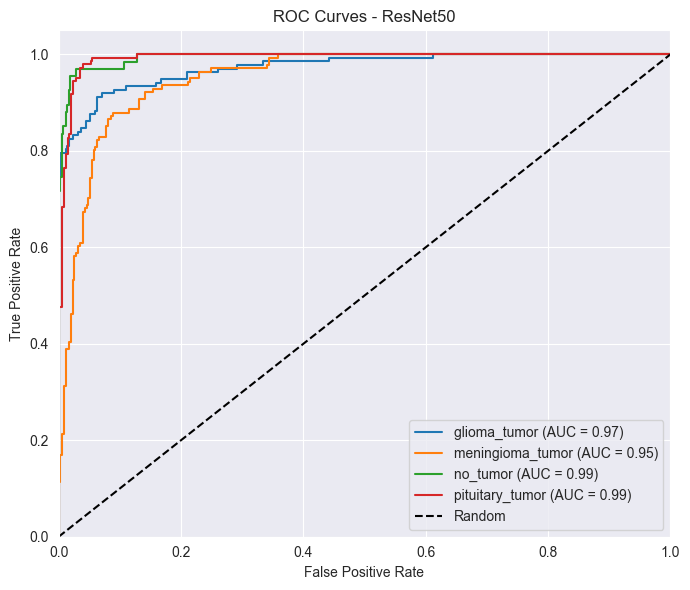

In [16]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = 4
y_true_bin = label_binarize(test_trues, classes=list(range(n_classes)))
# test_probs already shape: [N, 4]

plt.figure(figsize=(7, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - ResNet50")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Hook to capture activations and gradients
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        # Forward hook
        def forward_hook(module, input, output):
            self.activations = output

        # Full backward hook
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        self.fwd_handle = target_layer.register_forward_hook(forward_hook)
        self.bwd_handle = target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        loss = output[0, class_idx]
        loss.backward()

        grads = self.gradients
        acts = self.activations

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = cam[0, 0].detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def close(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

In [28]:
target_layer = model.layer4[-1].conv3
gradcam = GradCAM(model, target_layer)

RuntimeError: Cannot use both regular backward hooks and full backward hooks on a single Module. Please use only one of them.

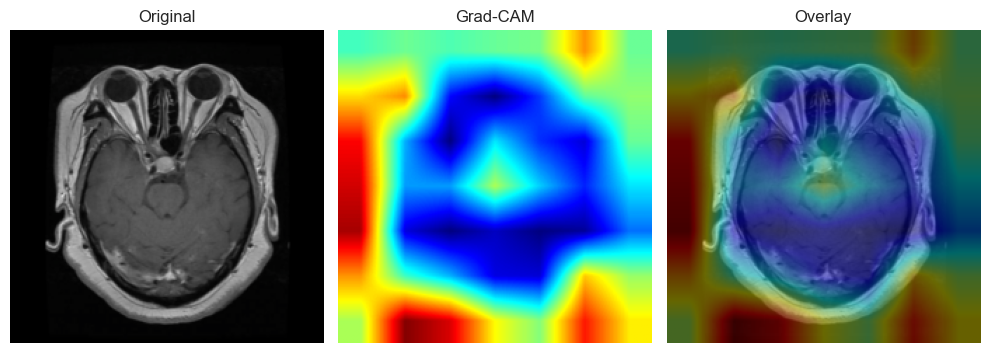

In [29]:
# Get one batch
images, labels = next(iter(test_loader))
image = images[0:1].to(device)  # shape [1, 3, 224, 224]

# Generate CAM
cam = gradcam.generate(image)

# Convert tensor image to numpy for display
img_np = images[0].permute(1, 2, 0).numpy()
# Undo normalization (approx)
img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img_np = np.clip(img_np, 0, 1)

# Resize CAM to image size
cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))

heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

overlay = 0.4 * heatmap + 0.6 * img_np

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img_np)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Grad-CAM")
plt.imshow(heatmap)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()